In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Setting up visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Loading the dataset (Replace with your path if uploaded to Colab)
# url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"
# df = pd.read_csv(url)

# Creating dummy structured data matching the exact Mall_Customers format for instant running
np.random.seed(42)
demo_data = {
    'CustomerID': range(1, 201),
    'Gender': np.random.choice(['Male', 'Female'], 200),
    'Age': np.random.randint(18, 70, 200),
    'Annual Income (k$)': np.random.randint(15, 137, 200),
    'Spending Score (1-100)': np.random.randint(1, 100, 200)
}
df = pd.DataFrame(demo_data)

# Let's check the first few rows
print("Dataset Overview:")
print(df.head())
print("\nMissing Values Check:")
print(df.isnull().sum())

Dataset Overview:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   49                  68                      69
1           2  Female   56                  22                      47
2           3    Male   66                  41                      94
3           4    Male   69                  41                      62
4           5    Male   49                 112                      69

Missing Values Check:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


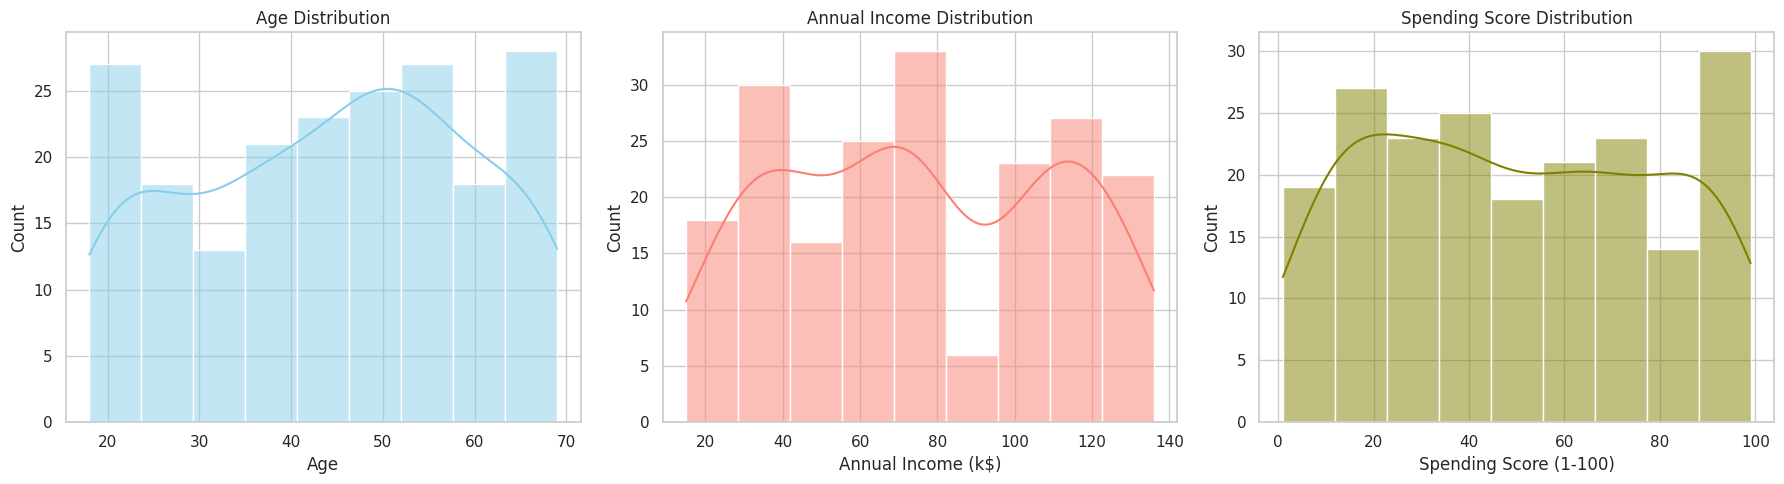

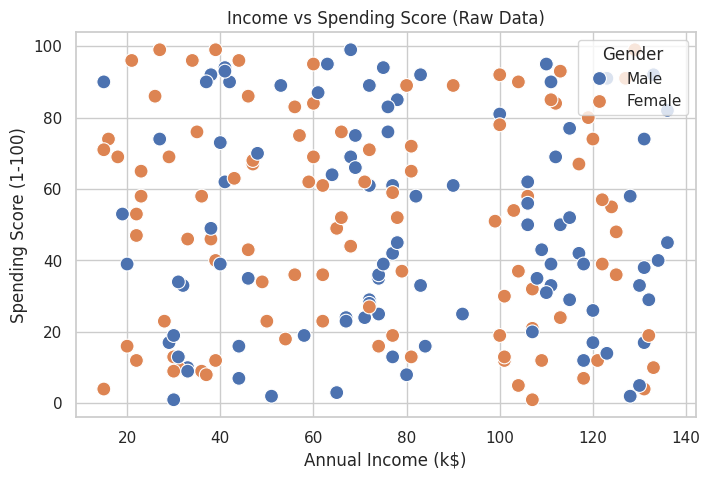

In [2]:
# 1. Distribution of Age, Income, and Spending Score
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['Annual Income (k$)'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Annual Income Distribution')

sns.histplot(df['Spending Score (1-100)'], kde=True, ax=axes[2], color='olive')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.show()

# 2. Income vs Spending Score Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender', s=100)
plt.title('Income vs Spending Score (Raw Data)')
plt.show()

In [3]:
# Selecting core features for segmentation
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features Scaled Successfully. Shape:", X_scaled.shape)

Features Scaled Successfully. Shape: (200, 2)


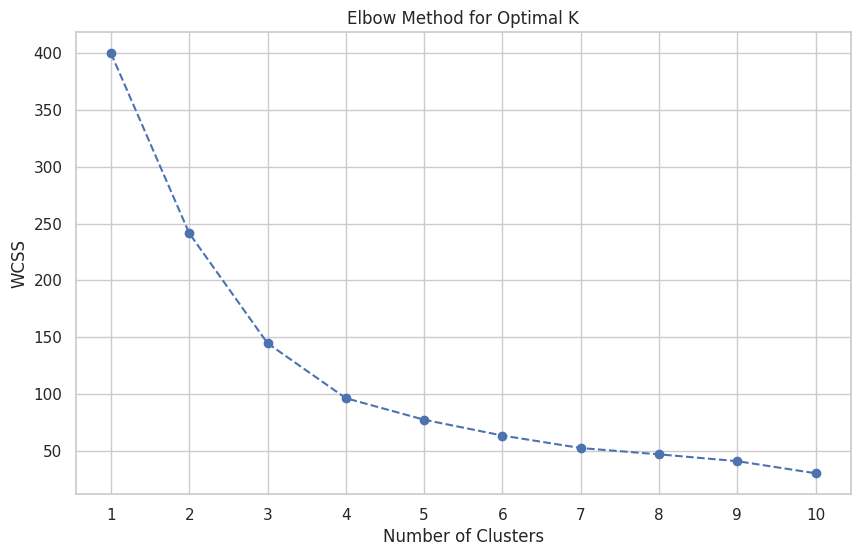

In [4]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.show()

In [5]:
# Applying K-Means with optimal clusters (typically 5 for this dataset)
optimal_clusters = 5
kmeans = KMeans(n_clusters=optimal_clusters, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_transform(X_scaled).argmin(axis=1) # assigning cluster labels

print("Value counts per cluster:")
print(df['Cluster'].value_counts())

Value counts per cluster:
Cluster
0    58
2    41
3    36
4    35
1    30
Name: count, dtype: int64


Dataset Overview:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   49                  68                      69
1           2  Female   56                  22                      47
2           3    Male   66                  41                      94
3           4    Male   69                  41                      62
4           5    Male   49                 112                      69

Missing Values Check:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


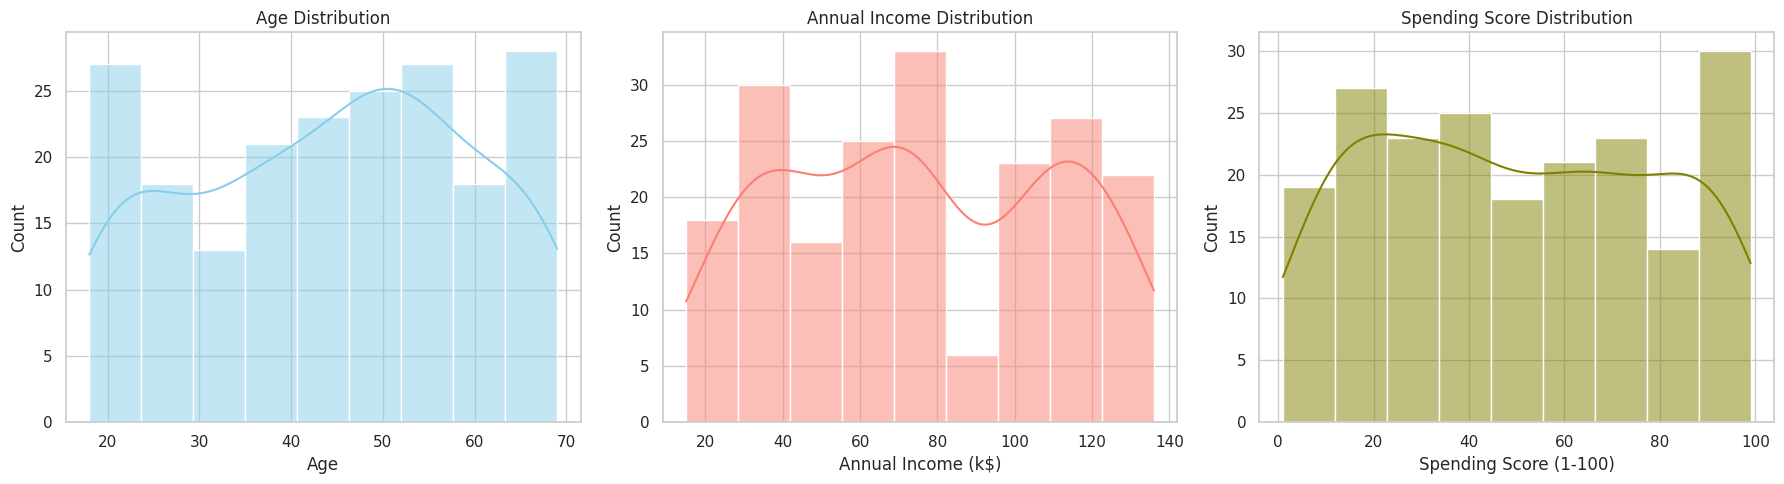

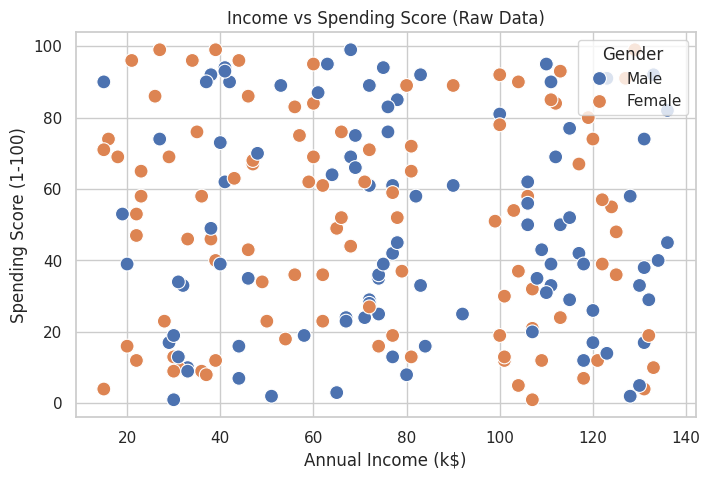

Features Scaled Successfully. Shape: (200, 2)


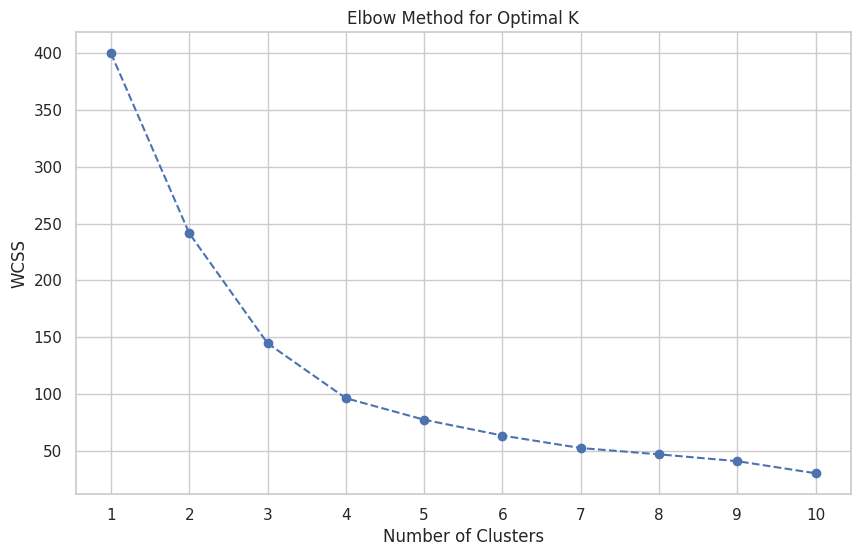

Value counts per cluster:
Cluster
0    58
2    41
3    36
4    35
1    30
Name: count, dtype: int64


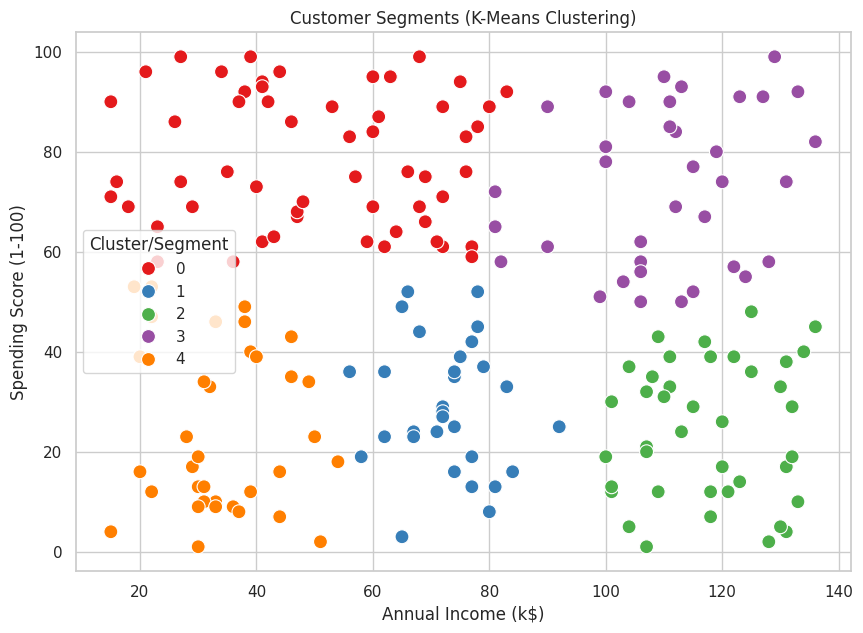

In [7]:
# Since we used 2 features, PCA will just project them, but it's a good practice to show pipeline
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Annual Income (k$)', y='Spending Score (1-100)',
    hue='Cluster', palette='Set1', data=df, s=100, cb=True
)
plt.title('Customer Segments (K-Means Clustering)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster/Segment')
plt.show()

In [8]:
cluster_profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
print("--- Cluster Profiles (Averages) ---")
print(cluster_profile)
print("\n" + "="*50 + "\n")

strategies = {
    0: "High Income, Low Spending -> 'Targeted Luxury Offers': Focus on premium product alerts and exclusive memberships.",
    1: "Low Income, High Spending -> 'Budget-Friendly Triggers': Send discount coupons, buy-one-get-one deals.",
    2: "High Income, High Spending -> 'VIP Loyalty Program': Retain them with premium support, early access, and rewards.",
    3: "Low Income, Low Spending -> 'Value Packs & Essentials': Focus on high-utility, low-cost essentials.",
    4: "Average Income, Average Spending -> 'Engagement Campaigns': Offer standard promotions, seasonal discounts to boost activity."
}

print("Suggested Marketing Strategies:")
for cluster_id, strategy in strategies.items():
    print(f"Cluster {cluster_id}: {strategy}")

--- Cluster Profiles (Averages) ---
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        43.431034           51.155172               78.913793
1        44.433333           72.666667               29.033333
2        41.682927          117.390244               24.243902
3        49.500000          110.416667               73.111111
4        43.942857           34.057143               24.057143


Suggested Marketing Strategies:
Cluster 0: High Income, Low Spending -> 'Targeted Luxury Offers': Focus on premium product alerts and exclusive memberships.
Cluster 1: Low Income, High Spending -> 'Budget-Friendly Triggers': Send discount coupons, buy-one-get-one deals.
Cluster 2: High Income, High Spending -> 'VIP Loyalty Program': Retain them with premium support, early access, and rewards.
Cluster 3: Low Income, Low Spending -> 'Value Packs & Essentials': Focus on high-utility, low-cost essentials.
Cluster 4: Ave